In [1]:
# Unified Stress and Anxiety Prediction Experiments
# All models use the same train/test split and cross-validation methodology

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from math import sqrt

# Model imports
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Deep learning imports (LSTM)
DL_AVAILABLE = False
try:
    import tensorflow as tf
    # Try tensorflow.keras first (TF 2.x standard)
    try:
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout
        from tensorflow.keras.optimizers import Adam
        from tensorflow.keras import callbacks
        keras = tf.keras
        DL_AVAILABLE = True
        print("TensorFlow/Keras loaded successfully (tensorflow.keras)")
    except (ImportError, AttributeError, ModuleNotFoundError) as e1:
        # Fallback: try standalone keras with tensorflow backend
        try:
            import os
            os.environ['KERAS_BACKEND'] = 'tensorflow'
            import keras
            from keras.models import Sequential
            from keras.layers import LSTM, Dense, Dropout
            from keras.optimizers import Adam
            from keras import callbacks
            DL_AVAILABLE = True
            print("TensorFlow/Keras loaded successfully (standalone keras)")
        except Exception as e2:
            print(f"Warning: Could not load TensorFlow/Keras. LSTM models will be skipped.")
            print(f"  tensorflow.keras error: {type(e1).__name__}: {e1}")
            print(f"  standalone keras error: {type(e2).__name__}: {e2}")
            print(f"  Suggestion: Try 'pip install tensorflow==2.15.0' or 'pip install --upgrade tensorflow'")
            DL_AVAILABLE = False
except ImportError as e:
    print(f"Warning: TensorFlow not installed. LSTM models will be skipped.")
    print(f"  Error: {e}")
    print(f"  Suggestion: Install with 'pip install tensorflow'")
    DL_AVAILABLE = False

# Configuration
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_PATH = Path("masterfiles/all_users_all_metrics.csv")
SEED = 42
np.random.seed(SEED)

# Target columns
TARGET_STRESS = "dq_stress level"
TARGET_ANX = "dq_anxiety level"


TensorFlow/Keras loaded successfully (tensorflow.keras)


## 1. Data Loading and Basic Cleaning


In [2]:
# Load data
df = pd.read_csv(DATA_PATH)

# Normalize core types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["user_id"] = df["user_id"].astype(str)

# Drop rows without date or user_id
df = df.dropna(subset=["date", "user_id"]).copy()

# Sort by user and date
df = df.sort_values(["user_id", "date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
df.head()


Shape: (3467, 14)
Date range: 2025-01-30 00:00:00 → 2025-07-01 00:00:00


,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0


## 2. Aggregate to Daily Level


In [3]:
# Aggregate to daily level (mean of numeric columns per user per day)
df["day"] = df["date"].dt.floor("D")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

daily = (df.groupby(["user_id", "day"], as_index=False)[num_cols]
           .mean()
           .sort_values(["user_id", "day"]))

daily = daily.rename(columns={"day": "date"})
print("Daily shape:", daily.shape)
daily.head()


Daily shape: (3467, 14)


,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0


## 3. Feature Engineering


In [4]:
# Create calendar features
daily["dow"] = daily["date"].dt.dayofweek
daily["is_weekend"] = (daily["dow"] >= 5).astype(int)

# Gap features
daily["gap_since_last_day"] = daily.groupby("user_id")["date"].diff().dt.days
daily["gap_since_last_day"] = daily["gap_since_last_day"].fillna(0).clip(lower=0, upper=30)
daily["data_gap"] = (daily["gap_since_last_day"] > 2).astype(int)

# Create target t+1 (shift forward by user)
for target in [TARGET_STRESS, TARGET_ANX]:
    if target in daily.columns:
        daily[f"{target}_tplus1"] = daily.groupby("user_id")[target].shift(-1)
        daily[f"{target}_t"] = daily[target]
        daily[f"{target}_lag1"] = daily.groupby("user_id")[target].shift(1)
        daily[f"{target}_ma7"] = daily.groupby("user_id")[target].transform(
            lambda s: s.rolling(7, min_periods=1).mean()
        )

daily.head()


,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level,dow,is_weekend,gap_since_last_day,data_gap,dq_stress level_tplus1,dq_stress level_t,dq_stress level_lag1,dq_stress level_ma7,dq_anxiety level_tplus1,dq_anxiety level_t,dq_anxiety level_lag1,dq_anxiety level_ma7
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0,1,0,0.0,0,33.0,15.0,NaN,15.00,0.0,0.0,NaN,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0,2,0,1.0,0,12.0,33.0,15.0,24.00,0.0,0.0,0.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0,3,0,1.0,0,9.0,12.0,33.0,20.00,8.0,0.0,0.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0,4,0,1.0,0,4.0,9.0,12.0,17.25,7.0,8.0,0.0,2.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,5,1,1.0,0,37.0,4.0,9.0,14.60,16.0,7.0,8.0,3.0


## 4. Imputation and Missing Flags


In [5]:
# Features to impute
FEATURES_FOR_IMPUTE = [
    "overall_score_previous_day",
    "deep_sleep_in_minutes_previous_day",
    "overall_score",
    "deep_sleep_in_minutes",
    "oxygen_saturation_average_value",
    "oxygen_saturation_average_value_previous_day",
    "rmssd",
    "rmssd_previous_day",
    "daily_respiratory_rate",
    "daily_respiratory_rate_previous_day",
]

FEATURES_FOR_IMPUTE = [c for c in FEATURES_FOR_IMPUTE if c in daily.columns]

# Create missing flags before imputation
for c in FEATURES_FOR_IMPUTE:
    daily[f"{c}_was_imputed"] = daily[c].isna().astype(int)

# Imputation: forward-fill by user, then rolling mean, then user mean, then global mean
def impute_user(g, cols, win=7):
    g = g.sort_values("date").copy()
    for c in cols:
        # Forward-fill
        g[c] = g[c].ffill()
        # Rolling mean for remaining NaNs
        g[c] = g[c].fillna(g[c].rolling(win, min_periods=1).mean())
        # User mean
        user_mean = g[c].mean()
        g[c] = g[c].fillna(user_mean)
    return g

daily = (daily.groupby("user_id", group_keys=False)
             .apply(impute_user, cols=FEATURES_FOR_IMPUTE, win=7)
             .reset_index(drop=True))

# Global mean for any remaining NaNs
for c in FEATURES_FOR_IMPUTE:
    daily[c] = daily[c].fillna(daily[c].mean())

print("Imputation complete")


Imputation complete


C:\Users\jorge\AppData\Local\Temp\ipykernel_22416\3734438678.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(impute_user, cols=FEATURES_FOR_IMPUTE, win=7)


## 5. Feature Selection


In [6]:
# Base features for modeling
base_feats = []

# Calendar features
base_feats += ["dow", "is_weekend", "gap_since_last_day", "data_gap"]

# Target-derived features (will be added per target)
# Physiological features
base_feats += FEATURES_FOR_IMPUTE

# Imputation flags
base_feats += [f"{c}_was_imputed" for c in FEATURES_FOR_IMPUTE]

print("Base features count:", len(base_feats))
print("Features:", base_feats)


Base features count: 24
Features: ['dow', 'is_weekend', 'gap_since_last_day', 'data_gap', 'overall_score_previous_day', 'deep_sleep_in_minutes_previous_day', 'overall_score', 'deep_sleep_in_minutes', 'oxygen_saturation_average_value', 'oxygen_saturation_average_value_previous_day', 'rmssd', 'rmssd_previous_day', 'daily_respiratory_rate', 'daily_respiratory_rate_previous_day', 'overall_score_previous_day_was_imputed', 'deep_sleep_in_minutes_previous_day_was_imputed', 'overall_score_was_imputed', 'deep_sleep_in_minutes_was_imputed', 'oxygen_saturation_average_value_was_imputed', 'oxygen_saturation_average_value_previous_day_was_imputed', 'rmssd_was_imputed', 'rmssd_previous_day_was_imputed', 'daily_respiratory_rate_was_imputed', 'daily_respiratory_rate_previous_day_was_imputed']


## 6. Train/Test Split (Chronological - Same for All Models)


In [47]:
# Filter to rows with non-null targets BEFORE splitting
# This ensures we split 80/20 of the USABLE data, not all data
# This also ensures regression and classification use the same train/test sets
target_cols = [f"{TARGET_STRESS}_tplus1", f"{TARGET_ANX}_tplus1"]
print("Before filtering:")
print(f"  Total rows: {len(daily)}")
print(f"  Rows with both targets non-null: {daily[target_cols].notna().all(axis=1).sum()}")

# Filter to rows where both target values are non-null
daily_usable = daily[daily[target_cols].notna().all(axis=1)].copy()
print(f"  Usable rows (both targets present): {len(daily_usable)} ({len(daily_usable)/len(daily)*100:.1f}%)")

# Chronological split: 80% train, 20% test (on USABLE data only)
# Sort by date to ensure chronological order
daily_usable = daily_usable.sort_values("date").reset_index(drop=True)
all_dates = np.sort(daily_usable["date"].dropna().unique())
cut_idx = int(0.8 * len(all_dates))
cut_date = all_dates[cut_idx]

train = daily_usable[daily_usable["date"] <= cut_date].copy()
test = daily_usable[daily_usable["date"] > cut_date].copy()

print("\nAfter filtering and splitting:")
print(f"Split date (inclusive to train): {cut_date}")
print(f"Train: {train['date'].min()} → {train['date'].max()}, rows: {len(train)} ({len(train)/len(daily_usable)*100:.1f}% of usable)")
print(f"Test : {test['date'].min()} → {test['date'].max()}, rows: {len(test)} ({len(test)/len(daily_usable)*100:.1f}% of usable)")


Before filtering:
  Total rows: 3467
  Rows with both targets non-null: 2886
  Usable rows (both targets present): 2886 (83.2%)

After filtering and splitting:
Split date (inclusive to train): 2025-05-09T00:00:00.000000000
Train: 2025-01-30 00:00:00 → 2025-05-09 00:00:00, rows: 2328 (80.7% of usable)
Test : 2025-05-10 00:00:00 → 2025-06-02 00:00:00, rows: 558 (19.3% of usable)


## 7. Evaluation Metrics


In [48]:
def mae(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = ~(np.isnan(y) | np.isnan(yhat))
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(y[mask] - yhat[mask])))

def rmse(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = ~(np.isnan(y) | np.isnan(yhat))
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((y[mask] - yhat[mask]) ** 2)))

def r2(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = ~(np.isnan(y) | np.isnan(yhat))
    if mask.sum() == 0:
        return np.nan
    return float(r2_score(y[mask], yhat[mask]))

def pearson_r(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = ~(np.isnan(y) | np.isnan(yhat))
    if mask.sum() < 2:
        return np.nan
    return float(pearsonr(y[mask], yhat[mask])[0])


## 8. Baseline Models

**Note:** Baselines are computed on the full dataset (train + test) to ensure they have proper historical context, then evaluated only on test set.


In [49]:
# Create baseline predictions on FULL dataset (train + test) for proper history
# Then we'll extract only test predictions for evaluation
targets = [c for c in [TARGET_STRESS, TARGET_ANX] if c in daily.columns]

# Combine train and test for baseline computation (preserve order)
full_data = pd.concat([train, test], ignore_index=True).sort_values(["user_id", "date"]).reset_index(drop=True)

for t in targets:
    # Last value (use current value at time t as prediction for t+1)
    full_data[f"{t}_pred_LV"] = full_data[t]
    
    # Moving average 7 (rolling window of 7 days)
    full_data[f"{t}_pred_MA7"] = full_data.groupby("user_id")[t].transform(
        lambda s: s.rolling(7, min_periods=1).mean()
    )
    
    # Expanding mean (mean of all previous values)
    full_data[f"{t}_pred_MEAN"] = full_data.groupby("user_id")[t].transform(
        lambda s: s.expanding(min_periods=1).mean()
    )
    
    # Expanding median (median of all previous values)
    full_data[f"{t}_pred_MEDIAN"] = full_data.groupby("user_id")[t].transform(
        lambda s: s.expanding(min_periods=1).median()
    )

# Extract baseline predictions for test set by merging on user_id and date
baseline_cols = []
for t in targets:
    baseline_cols.extend([f"{t}_pred_LV", f"{t}_pred_MA7", f"{t}_pred_MEAN", f"{t}_pred_MEDIAN"])

test = test.merge(
    full_data[["user_id", "date"] + baseline_cols],
    on=["user_id", "date"],
    how="left",
    suffixes=("", "_from_full")
)

# If merge created duplicate columns, keep the ones from full_data
for col in baseline_cols:
    if f"{col}_from_full" in test.columns:
        test[col] = test[f"{col}_from_full"]
        test = test.drop(columns=[f"{col}_from_full"])

print("Baseline predictions created (using full dataset history)")
print(f"Test set shape: {test.shape}")


Baseline predictions created (using full dataset history)
Test set shape: (558, 44)


## 9. Baseline Evaluation


In [50]:
baseline_results = []

for t in targets:
    y_true = test[f"{t}_tplus1"]
    
    for baseline_name in ["LV", "MA7", "MEAN", "MEDIAN"]:
        y_pred = test[f"{t}_pred_{baseline_name}"]
        
        baseline_results.append({
            "target": t,
            "model": baseline_name,
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "R2": r2(y_true, y_pred),
            "Pearson_r": pearson_r(y_true, y_pred),
        })

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)


,target,model,MAE,RMSE,R2,Pearson_r
0,dq_stress level,LV,16.117318,24.265869,-0.093173,0.466538
1,dq_stress level,MA7,13.955061,20.286692,0.270526,0.575500
2,dq_stress level,MEAN,15.899096,20.356655,0.265486,0.543271
3,dq_stress level,MEDIAN,15.038530,20.882447,0.227053,0.526059
4,dq_anxiety level,LV,16.716946,24.784847,0.105472,0.559143
5,dq_anxiety level,MA7,15.160885,20.968959,0.386492,0.641998
6,dq_anxiety level,MEAN,18.266386,23.165254,0.251243,0.515582
7,dq_anxiety level,MEDIAN,18.215950,24.709087,0.148117,0.471997


## 10. Linear Models (OLS, Lasso, Elastic Net)


In [51]:
# Helper functions for standardization
def fit_stats(X):
    mu = X.mean(0)
    sd = X.std(0).replace(0, 1.0)
    return mu, sd

def apply_stats(X, mu, sd):
    return (X - mu) / sd

def take_xy(df, ylab, feat_list):
    df2 = df.dropna(subset=[ylab] + feat_list).copy()
    X = df2[feat_list].astype(float)
    y = df2[ylab].astype(float)
    return df2, X, y

linear_results = []
linear_coefs = {}

# First, prepare data for all targets and find best hyperparameters across all targets
target_data = {}
for t in targets:
    ylab = f"{t}_tplus1"
    
    # Add target-derived features for this specific target
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data
    tr_df, Xtr, ytr = take_xy(train, ylab, feat_list)
    te_df, Xte, yte = take_xy(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    target_data[t] = {
        "ylab": ylab,
        "feat_list": feat_list,
        "tr_df": tr_df,
        "Xtr": Xtr,
        "ytr": ytr,
        "te_df": te_df,
        "Xte": Xte,
        "yte": yte
    }

# Find best hyperparameters by averaging validation MAE across all targets
alpha_grid = [0.001, 0.005, 0.01, 0.05, 0.1]
best_lasso_alpha = None
best_lasso_mae = np.inf
best_en_params = {"mae": np.inf, "alpha": None, "l1r": None}

print("Tuning hyperparameters across all targets...")
for a in alpha_grid:
    # Lasso: average validation MAE across all targets
    lasso_maes = []
    for t, data in target_data.items():
        tr_df = data["tr_df"]
        feat_list = data["feat_list"]
        ylab = data["ylab"]
        
        # Time-aware validation split
        tr_dates = np.sort(tr_df["date"].unique())
        cut_i = int(0.8 * len(tr_dates))
        cut_d = tr_dates[cut_i]
        
        tr_in = tr_df[tr_df["date"] <= cut_d]
        va_in = tr_df[tr_df["date"] > cut_d]
        
        Xtri = tr_in[feat_list].astype(float)
        ytri = tr_in[ylab].astype(float)
        Xvai = va_in[feat_list].astype(float)
        yvai = va_in[ylab].astype(float)
        
        mu_i, sd_i = fit_stats(Xtri)
        Xtri_s = apply_stats(Xtri, mu_i, sd_i)
        Xvai_s = apply_stats(Xvai, mu_i, sd_i)
        
        ltmp = Lasso(alpha=a, max_iter=10000, random_state=SEED)
        ltmp.fit(Xtri_s, ytri)
        pv = ltmp.predict(Xvai_s)
        lasso_maes.append(mae(yvai, pv))
    
    avg_mae = np.mean(lasso_maes)
    if avg_mae < best_lasso_mae:
        best_lasso_mae = avg_mae
        best_lasso_alpha = a

# ElasticNet: average validation MAE across all targets
for a in alpha_grid:
    for l1r in [0.2, 0.5, 0.8]:
        en_maes = []
        for t, data in target_data.items():
            tr_df = data["tr_df"]
            feat_list = data["feat_list"]
            ylab = data["ylab"]
            
            # Time-aware validation split
            tr_dates = np.sort(tr_df["date"].unique())
            cut_i = int(0.8 * len(tr_dates))
            cut_d = tr_dates[cut_i]
            
            tr_in = tr_df[tr_df["date"] <= cut_d]
            va_in = tr_df[tr_df["date"] > cut_d]
            
            Xtri = tr_in[feat_list].astype(float)
            ytri = tr_in[ylab].astype(float)
            Xvai = va_in[feat_list].astype(float)
            yvai = va_in[ylab].astype(float)
            
            mu_i, sd_i = fit_stats(Xtri)
            Xtri_s = apply_stats(Xtri, mu_i, sd_i)
            Xvai_s = apply_stats(Xvai, mu_i, sd_i)
            
            entmp = ElasticNet(alpha=a, l1_ratio=l1r, max_iter=10000, random_state=SEED)
            entmp.fit(Xtri_s, ytri)
            pv = entmp.predict(Xvai_s)
            en_maes.append(mae(yvai, pv))
        
        avg_mae = np.mean(en_maes)
        if avg_mae < best_en_params["mae"]:
            best_en_params = {"mae": avg_mae, "alpha": a, "l1r": l1r}

print(f"Best Lasso alpha: {best_lasso_alpha} (avg validation MAE: {best_lasso_mae:.3f})")
print(f"Best ElasticNet: alpha={best_en_params['alpha']}, l1_ratio={best_en_params['l1r']} (avg validation MAE: {best_en_params['mae']:.3f})")

# Now train models on all targets using the same hyperparameters
for t, data in target_data.items():
    ylab = data["ylab"]
    feat_list = data["feat_list"]
    Xtr = data["Xtr"]
    ytr = data["ytr"]
    Xte = data["Xte"]
    yte = data["yte"]
    
    # Standardize
    mu, sd = fit_stats(Xtr)
    Xtr_s = apply_stats(Xtr, mu, sd)
    Xte_s = apply_stats(Xte, mu, sd)

    # OLS
    lr = LinearRegression()
    lr.fit(Xtr_s, ytr)
    pred_lr = lr.predict(Xte_s)

    linear_results.append({
        "target": t,
        "model": "OLS",
        "MAE": mae(yte, pred_lr),
        "RMSE": rmse(yte, pred_lr),
        "R2": r2(yte, pred_lr),
        "Pearson_r": pearson_r(yte, pred_lr),
    })

    linear_coefs[f"{t}_OLS"] = pd.Series(lr.coef_, index=feat_list).sort_values(
        key=np.abs, ascending=False
    )

    # Lasso with shared hyperparameters
    lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000, random_state=SEED)
    lasso.fit(Xtr_s, ytr)
    pred_lasso = lasso.predict(Xte_s)

    linear_results.append({
        "target": t,
        "model": f"Lasso (α={best_lasso_alpha})",
        "MAE": mae(yte, pred_lasso),
        "RMSE": rmse(yte, pred_lasso),
        "R2": r2(yte, pred_lasso),
        "Pearson_r": pearson_r(yte, pred_lasso),
    })

    linear_coefs[f"{t}_Lasso"] = pd.Series(lasso.coef_, index=feat_list).sort_values(
        key=np.abs, ascending=False
    )

    # ElasticNet with shared hyperparameters
    en = ElasticNet(alpha=best_en_params["alpha"], l1_ratio=best_en_params["l1r"], max_iter=10000, random_state=SEED)
    en.fit(Xtr_s, ytr)
    pred_en = en.predict(Xte_s)

    linear_results.append({
        "target": t,
        "model": f"ElasticNet (α={best_en_params['alpha']}, l1r={best_en_params['l1r']})",
        "MAE": mae(yte, pred_en),
        "RMSE": rmse(yte, pred_en),
        "R2": r2(yte, pred_en),
        "Pearson_r": pearson_r(yte, pred_en),
    })

    linear_coefs[f"{t}_ElasticNet"] = pd.Series(en.coef_, index=feat_list).sort_values(
        key=np.abs, ascending=False
    )

linear_df = pd.DataFrame(linear_results)
display(linear_df)


Tuning hyperparameters across all targets...
Best Lasso alpha: 0.1 (avg validation MAE: 12.258)
Best ElasticNet: alpha=0.1, l1_ratio=0.8 (avg validation MAE: 12.287)


,target,model,MAE,RMSE,R2,Pearson_r
0,dq_stress level,OLS,14.238556,19.916463,0.270115,0.543702
1,dq_stress level,Lasso (α=0.1),14.146943,19.841544,0.275596,0.546222
2,dq_stress level,"ElasticNet (α=0.1, l1r=0.8)",14.184079,19.817755,0.277332,0.546075
3,dq_anxiety level,OLS,15.225067,20.478421,0.387249,0.627790
4,dq_anxiety level,Lasso (α=0.1),15.097013,20.379901,0.393131,0.631445
5,dq_anxiety level,"ElasticNet (α=0.1, l1r=0.8)",15.124054,20.374284,0.393465,0.631232


## 11. Linear Models Cross Validation


In [52]:
cv_n_splits = 5
cv_min_rows = 80

cv_results = []

for t in targets:
    ylab = f"{t}_tplus1"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data from train set only
    cols = ["date"] + feat_list + [ylab]
    T = train[cols].copy()
    T = T.dropna(subset=[ylab] + feat_list).copy()
    T = T.sort_values("date").reset_index(drop=True)
    
    if len(T) < cv_min_rows:
        print(f"[{t}] Not enough rows for CV (got {len(T)}). Skipping.")
        continue
    
    # TimeSeriesSplit
    udates = np.unique(T["date"].values)
    n_splits = min(cv_n_splits, max(2, len(udates) // 10))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    X = T[feat_list].astype(float)
    y = T[ylab].astype(float)
    
    fold = 0
    for tr_idx, va_idx in tscv.split(X):
        fold += 1
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
        
        # Standardize
        mu = Xtr.mean(0)
        sd = Xtr.std(0).replace(0, 1.0)
        Xtr_s = (Xtr - mu) / sd
        Xva_s = (Xva - mu) / sd
        
        # Fit OLS
        lr = LinearRegression()
        lr.fit(Xtr_s, ytr)
        p = lr.predict(Xva_s)
        
        cv_results.append({
            "target": t,
            "model": "OLS",
            "fold": fold,
            "n_train": len(Xtr),
            "n_val": len(Xva),
            "MAE": mae(yva, p),
            "RMSE": rmse(yva, p),
            "R2": r2(yva, p),
        })

cv_df = pd.DataFrame(cv_results)
if not cv_df.empty:
    cv_summary = (cv_df.groupby(["target", "model"])[["MAE", "RMSE", "R2"]]
                  .agg(["mean", "std"])
                  .round(3))
    print("Time-series CV results (mean ± std):")
    display(cv_summary)
else:
    print("No CV results.")


Time-series CV results (mean ± std):


MAE           RMSE            R2       
                          mean    std    mean    std   mean    std
target           model                                            
dq_anxiety level OLS    15.442  1.765  20.388  2.339  0.461  0.134
dq_stress level  OLS    14.086  2.988  18.713  3.438  0.507  0.169

## 12. Tree Models (XGBoost, LightGBM)

In [53]:
tree_results = []

for t in targets:
    ylab = f"{t}_tplus1"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data
    tr_df, Xtr, ytr = take_xy(train, ylab, feat_list)
    te_df, Xte, yte = take_xy(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    # XGBoost
    xgb = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1
    )
    
    xgb.fit(Xtr, ytr)
    pred_xgb = xgb.predict(Xte)
    
    tree_results.append({
        "target": t,
        "model": "XGBoost",
        "MAE": mae(yte, pred_xgb),
        "RMSE": rmse(yte, pred_xgb),
        "R2": r2(yte, pred_xgb),
        "Pearson_r": pearson_r(yte, pred_xgb),
    })
    
    # LightGBM
    lgbm = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
    
    lgbm.fit(Xtr, ytr)
    pred_lgb = lgbm.predict(Xte)
    
    tree_results.append({
        "target": t,
        "model": "LightGBM",
        "MAE": mae(yte, pred_lgb),
        "RMSE": rmse(yte, pred_lgb),
        "R2": r2(yte, pred_lgb),
        "Pearson_r": pearson_r(yte, pred_lgb),
    })

tree_df = pd.DataFrame(tree_results)
display(tree_df)


,target,model,MAE,RMSE,R2,Pearson_r
0,dq_stress level,XGBoost,15.384545,20.931472,0.193824,0.483162
1,dq_stress level,LightGBM,15.357031,21.001690,0.188406,0.486684
2,dq_anxiety level,XGBoost,16.496625,22.177802,0.281333,0.555606
3,dq_anxiety level,LightGBM,17.029536,22.624690,0.252078,0.545321


## 13. Tree Models Cross-Validation


In [54]:
cv_tree_results = []

for t in targets:
    ylab = f"{t}_tplus1"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data from train set only
    cols = ["date"] + feat_list + [ylab]
    T = train[cols].copy()
    T = T.dropna(subset=[ylab] + feat_list).copy()
    T = T.sort_values("date").reset_index(drop=True)
    
    if len(T) < cv_min_rows:
        print(f"[{t}] Not enough rows for CV (got {len(T)}). Skipping.")
        continue
    
    # TimeSeriesSplit
    udates = np.unique(T["date"].values)
    n_splits = min(cv_n_splits, max(2, len(udates) // 10))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    X = T[feat_list].astype(float)
    y = T[ylab].astype(float)
    
    fold = 0
    for tr_idx, va_idx in tscv.split(X):
        fold += 1
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
        
        # XGBoost
        xgb = XGBRegressor(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=-1
        )
        xgb.fit(Xtr, ytr)
        p_xgb = xgb.predict(Xva)
        
        cv_tree_results.append({
            "target": t,
            "model": "XGBoost",
            "fold": fold,
            "n_train": len(Xtr),
            "n_val": len(Xva),
            "MAE": mae(yva, p_xgb),
            "RMSE": rmse(yva, p_xgb),
            "R2": r2(yva, p_xgb),
        })
        
        # LightGBM
        lgbm = LGBMRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1
        )
        lgbm.fit(Xtr, ytr)
        p_lgb = lgbm.predict(Xva)
        
        cv_tree_results.append({
            "target": t,
            "model": "LightGBM",
            "fold": fold,
            "n_train": len(Xtr),
            "n_val": len(Xva),
            "MAE": mae(yva, p_lgb),
            "RMSE": rmse(yva, p_lgb),
            "R2": r2(yva, p_lgb),
        })

cv_tree_df = pd.DataFrame(cv_tree_results)
if not cv_tree_df.empty:
    cv_tree_summary = (cv_tree_df.groupby(["target", "model"])[["MAE", "RMSE", "R2"]]
                       .agg(["mean", "std"])
                       .round(3))
    print("Time-series CV results for tree models (mean ± std):")
    display(cv_tree_summary)
else:
    print("No CV results for tree models.")


Time-series CV results for tree models (mean ± std):


MAE           RMSE            R2       
                             mean    std    mean    std   mean    std
target           model                                               
dq_anxiety level LightGBM  17.304  1.150  22.641  1.847  0.339  0.122
                 XGBoost   16.991  1.136  22.155  1.400  0.369  0.091
dq_stress level  LightGBM  15.645  1.695  20.525  2.340  0.415  0.113
                 XGBoost   15.857  1.904  20.750  2.456  0.401  0.126

## 14. All Models Comparison


### Model Performance Comparison Charts


In [55]:
# Combine all results
all_results = pd.concat([
    baseline_df,
    linear_df,
    tree_df
], ignore_index=True)

# Pivot tables for easier comparison
print("=== MAE (lower is better) ===")
display(all_results.pivot(index="target", columns="model", values="MAE").round(3))

print("\n=== RMSE (lower is better) ===")
display(all_results.pivot(index="target", columns="model", values="RMSE").round(3))

print("\n=== R2 (higher is better) ===")
display(all_results.pivot(index="target", columns="model", values="R2").round(3))

print("\n=== Pearson r (higher is better) ===")
display(all_results.pivot(index="target", columns="model", values="Pearson_r").round(3))


=== MAE (lower is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,
dq_anxiety level,15.124,16.717,15.097,17.030,15.161,18.266,18.216,15.225,16.497
dq_stress level,14.184,16.117,14.147,15.357,13.955,15.899,15.039,14.239,15.385



=== RMSE (lower is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,
dq_anxiety level,20.374,24.785,20.380,22.625,20.969,23.165,24.709,20.478,22.178
dq_stress level,19.818,24.266,19.842,21.002,20.287,20.357,20.882,19.916,20.931



=== R2 (higher is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,
dq_anxiety level,0.393,0.105,0.393,0.252,0.386,0.251,0.148,0.387,0.281
dq_stress level,0.277,-0.093,0.276,0.188,0.271,0.265,0.227,0.270,0.194



=== Pearson r (higher is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,
dq_anxiety level,0.631,0.559,0.631,0.545,0.642,0.516,0.472,0.628,0.556
dq_stress level,0.546,0.467,0.546,0.487,0.576,0.543,0.526,0.544,0.483


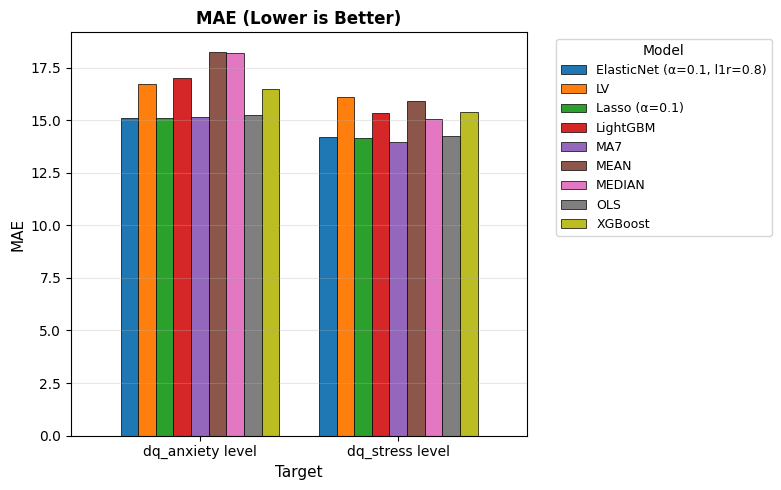

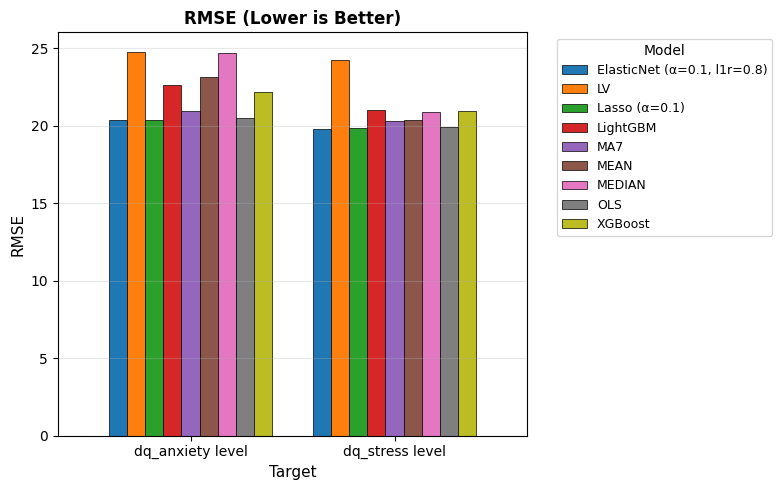

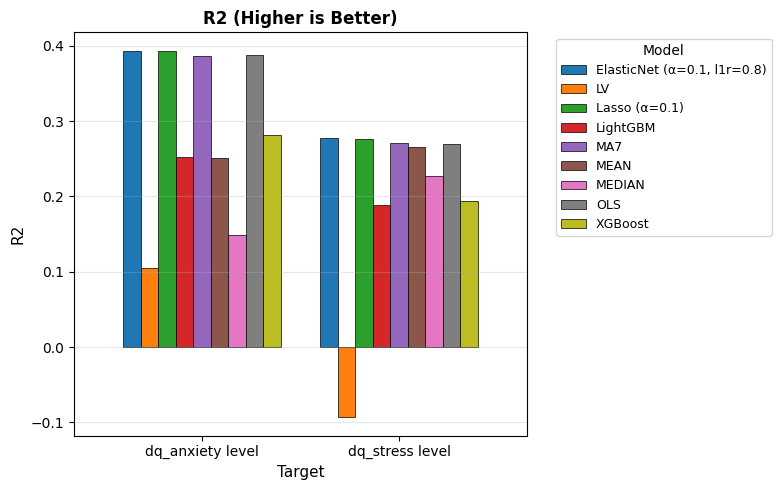

In [56]:
# Essential bar comparison charts (separate figures for each metric)
metrics = ['MAE', 'RMSE', 'R2']
for metric in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_data = all_results.pivot(index="target", columns="model", values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{metric} {"(Lower is Better)" if metric in ["MAE", "RMSE"] else "(Higher is Better)"}', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel('Target', fontsize=11)
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()


## 15. LSTM Models


In [57]:
# Helper function to create sequences for LSTM
def create_sequences(X, y, seq_length=7):
    """Create sequences of length seq_length for LSTM input.
    Uses features from t-seq_length+1 to t to predict t+1"""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:(i + seq_length)])
        y_seq.append(y[i + seq_length])  # Target is at t+1 (after the sequence)
    return np.array(X_seq), np.array(y_seq)

if DL_AVAILABLE:
    # Set random seed for reproducibility
    tf.random.set_seed(SEED)
    
    lstm_results = []
    seq_length = 7  
    
    for t in targets:
        ylab = f"{t}_tplus1"
        
        # Add target-derived features
        feat_list = base_feats.copy()
        feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
        feat_list = [f for f in feat_list if f in train.columns]
        
        # Prepare data
        tr_df, Xtr, ytr = take_xy(train, ylab, feat_list)
        te_df, Xte, yte = take_xy(test, ylab, feat_list)
        
        if len(tr_df) < seq_length or len(te_df) < seq_length:
            print(f"Skipping {t}: insufficient data for LSTM (need at least {seq_length} samples)")
            continue
        
        # Standardize features
        mu, sd = fit_stats(Xtr)
        Xtr_s = apply_stats(Xtr, mu, sd)
        Xte_s = apply_stats(Xte, mu, sd)
        
        # Create sequences
        Xtr_seq, ytr_seq = create_sequences(Xtr_s.values, ytr.values, seq_length)
        Xte_seq, yte_seq = create_sequences(Xte_s.values, yte.values, seq_length)
        
        if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
            print(f"Skipping {t}: could not create sequences")
            continue
        
        # Build LSTM model
        model = Sequential([
            LSTM(50, activation='relu', input_shape=(seq_length, len(feat_list)), return_sequences=True),
            Dropout(0.2),
            LSTM(50, activation='relu', return_sequences=False),
            Dropout(0.2),
            Dense(25, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
        
        # Train with early stopping
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
        
        # Time-aware validation split
        tr_dates = np.sort(tr_df["date"].unique())
        cut_i = int(0.8 * len(tr_dates))
        cut_d = tr_dates[cut_i]
        
        tr_in = tr_df[tr_df["date"] <= cut_d]
        va_in = tr_df[tr_df["date"] > cut_d]
        
        Xtri = tr_in[feat_list].astype(float)
        ytri = tr_in[ylab].astype(float)
        Xvai = va_in[feat_list].astype(float)
        yvai = va_in[ylab].astype(float)
        
        mu_i, sd_i = fit_stats(Xtri)
        Xtri_s = apply_stats(Xtri, mu_i, sd_i)
        Xvai_s = apply_stats(Xvai, mu_i, sd_i)
        
        Xtri_seq, ytri_seq = create_sequences(Xtri_s.values, ytri.values, seq_length)
        Xvai_seq, yvai_seq = create_sequences(Xvai_s.values, yvai.values, seq_length)
        
        if len(Xtri_seq) > 0 and len(Xvai_seq) > 0:
            history = model.fit(
                Xtri_seq, ytri_seq,
                validation_data=(Xvai_seq, yvai_seq),
                epochs=50,
                batch_size=32,
                callbacks=[early_stop],
                verbose=0
            )
        
        # Predict on test set
        pred_lstm = model.predict(Xte_seq, verbose=0).flatten()
        
        # Align predictions with actual values (sequences may have different length)
        min_len = min(len(yte_seq), len(pred_lstm))
        yte_aligned = yte_seq[:min_len]
        pred_aligned = pred_lstm[:min_len]
        
        lstm_results.append({
            "target": t,
            "model": "LSTM",
            "MAE": mae(yte_aligned, pred_aligned),
            "RMSE": rmse(yte_aligned, pred_aligned),
            "R2": r2(yte_aligned, pred_aligned),
            "Pearson_r": pearson_r(yte_aligned, pred_aligned),
        })
    
    lstm_df = pd.DataFrame(lstm_results)
    display(lstm_df)
else:
    print("LSTM models skipped (TensorFlow not available)")
    lstm_df = pd.DataFrame()


c:\Users\jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,target,model,MAE,RMSE,R2,Pearson_r
0,dq_stress level,LSTM,19.316979,23.950786,-0.048149,0.001903
1,dq_anxiety level,LSTM,23.104449,27.116778,-0.065242,-0.012660


## 16. LSTM Cross-Validation


In [58]:
if DL_AVAILABLE:
    cv_lstm_results = []
    seq_length = 7
    
    for t in targets:
        ylab = f"{t}_tplus1"
        
        # Add target-derived features
        feat_list = base_feats.copy()
        feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
        feat_list = [f for f in feat_list if f in train.columns]
        
        # Prepare data from train set only
        cols = ["date"] + feat_list + [ylab]
        T = train[cols].copy()
        T = T.dropna(subset=[ylab] + feat_list).copy()
        T = T.sort_values("date").reset_index(drop=True)
        
        if len(T) < cv_min_rows or len(T) < seq_length:
            print(f"[{t}] Not enough rows for CV (got {len(T)}). Skipping.")
            continue
        
        # TimeSeriesSplit
        udates = np.unique(T["date"].values)
        n_splits = min(cv_n_splits, max(2, len(udates) // 10))
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        X = T[feat_list].astype(float)
        y = T[ylab].astype(float)
        
        fold = 0
        for tr_idx, va_idx in tscv.split(X):
            fold += 1
            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
            
            if len(Xtr) < seq_length or len(Xva) < seq_length:
                continue
            
            # Standardize
            mu = Xtr.mean(0)
            sd = Xtr.std(0).replace(0, 1.0)
            Xtr_s = (Xtr - mu) / sd
            Xva_s = (Xva - mu) / sd
            
            # Create sequences
            Xtr_seq, ytr_seq = create_sequences(Xtr_s.values, ytr.values, seq_length)
            Xva_seq, yva_seq = create_sequences(Xva_s.values, yva.values, seq_length)
            
            if len(Xtr_seq) == 0 or len(Xva_seq) == 0:
                continue
            
            # Build and train LSTM model
            model = Sequential([
                LSTM(50, activation='relu', input_shape=(seq_length, len(feat_list)), return_sequences=True),
                Dropout(0.2),
                LSTM(50, activation='relu', return_sequences=False),
                Dropout(0.2),
                Dense(25, activation='relu'),
                Dense(1)
            ])
            
            model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
            
            # Train with early stopping
            early_stop = callbacks.EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )
            
            # Use a small validation split from training data for early stopping
            val_split = 0.2
            n_val = int(len(Xtr_seq) * val_split)
            if n_val > 0:
                Xtr_fit = Xtr_seq[:-n_val]
                ytr_fit = ytr_seq[:-n_val]
                Xtr_val = Xtr_seq[-n_val:]
                ytr_val = ytr_seq[-n_val:]
            else:
                Xtr_fit, ytr_fit = Xtr_seq, ytr_seq
                Xtr_val, ytr_val = Xtr_seq, ytr_seq
            
            model.fit(
                Xtr_fit, ytr_fit,
                validation_data=(Xtr_val, ytr_val) if n_val > 0 else None,
                epochs=30,
                batch_size=min(32, len(Xtr_fit)),
                callbacks=[early_stop],
                verbose=0
            )
            
            # Predict
            p = model.predict(Xva_seq, verbose=0).flatten()
            
            # Align lengths
            min_len = min(len(yva_seq), len(p))
            yva_aligned = yva_seq[:min_len]
            p_aligned = p[:min_len]
            
            cv_lstm_results.append({
                "target": t,
                "model": "LSTM",
                "fold": fold,
                "n_train": len(Xtr_seq),
                "n_val": len(Xva_seq),
                "MAE": mae(yva_aligned, p_aligned),
                "RMSE": rmse(yva_aligned, p_aligned),
                "R2": r2(yva_aligned, p_aligned),
            })
    
    cv_lstm_df = pd.DataFrame(cv_lstm_results)
    if not cv_lstm_df.empty:
        cv_lstm_summary = (cv_lstm_df.groupby(["target", "model"])[["MAE", "RMSE", "R2"]]
                          .agg(["mean", "std"])
                          .round(3))
        print("Time-series CV results for LSTM (mean ± std):")
        display(cv_lstm_summary)
    else:
        print("No CV results for LSTM.")
else:
    print("LSTM CV skipped (TensorFlow not available)")


c:\Users\jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\jorge\AppData\Local\Programs\Pytho

Time-series CV results for LSTM (mean ± std):


MAE           RMSE            R2       
                          mean    std    mean    std   mean    std
target           model                                            
dq_anxiety level LSTM   23.798  1.042  28.767  0.832 -0.058  0.056
dq_stress level  LSTM   22.962  0.623  28.191  0.896 -0.103  0.082

## 17. Extended Models Comparison (Including LSTM)


In [59]:
# Combine all results including new models
all_results_extended = pd.concat([
    baseline_df,
    linear_df,
    tree_df,
    lstm_df if DL_AVAILABLE else pd.DataFrame()
], ignore_index=True)

# Pivot tables for easier comparison
print("=== MAE (lower is better) ===")
display(all_results_extended.pivot(index="target", columns="model", values="MAE").round(3))

print("\n=== RMSE (lower is better) ===")
display(all_results_extended.pivot(index="target", columns="model", values="RMSE").round(3))

print("\n=== R2 (higher is better) ===")
display(all_results_extended.pivot(index="target", columns="model", values="R2").round(3))

print("\n=== Pearson r (higher is better) ===")
display(all_results_extended.pivot(index="target", columns="model", values="Pearson_r").round(3))


=== MAE (lower is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LSTM,LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,,
dq_anxiety level,15.124,23.104,16.717,15.097,17.030,15.161,18.266,18.216,15.225,16.497
dq_stress level,14.184,19.317,16.117,14.147,15.357,13.955,15.899,15.039,14.239,15.385



=== RMSE (lower is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LSTM,LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,,
dq_anxiety level,20.374,27.117,24.785,20.380,22.625,20.969,23.165,24.709,20.478,22.178
dq_stress level,19.818,23.951,24.266,19.842,21.002,20.287,20.357,20.882,19.916,20.931



=== R2 (higher is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LSTM,LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,,
dq_anxiety level,0.393,-0.065,0.105,0.393,0.252,0.386,0.251,0.148,0.387,0.281
dq_stress level,0.277,-0.048,-0.093,0.276,0.188,0.271,0.265,0.227,0.270,0.194



=== Pearson r (higher is better) ===


model,"ElasticNet (α=0.1, l1r=0.8)",LSTM,LV,Lasso (α=0.1),LightGBM,MA7,MEAN,MEDIAN,OLS,XGBoost
target,,,,,,,,,,
dq_anxiety level,0.631,-0.013,0.559,0.631,0.545,0.642,0.516,0.472,0.628,0.556
dq_stress level,0.546,0.002,0.467,0.546,0.487,0.576,0.543,0.526,0.544,0.483


### Model Performance Comparison Charts


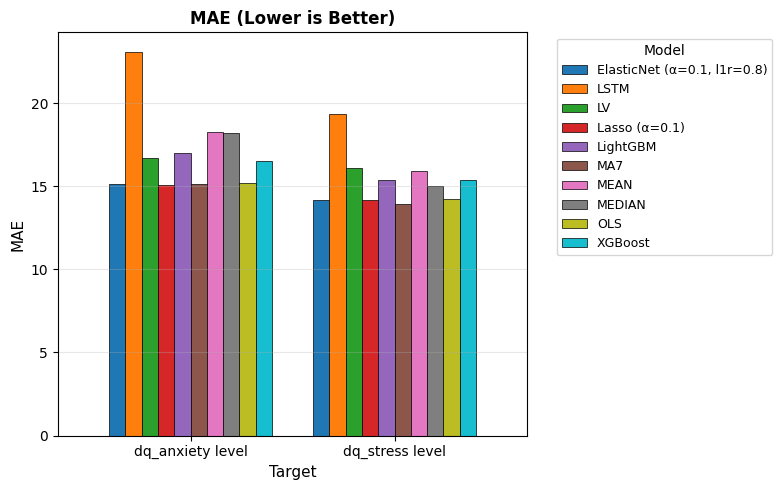

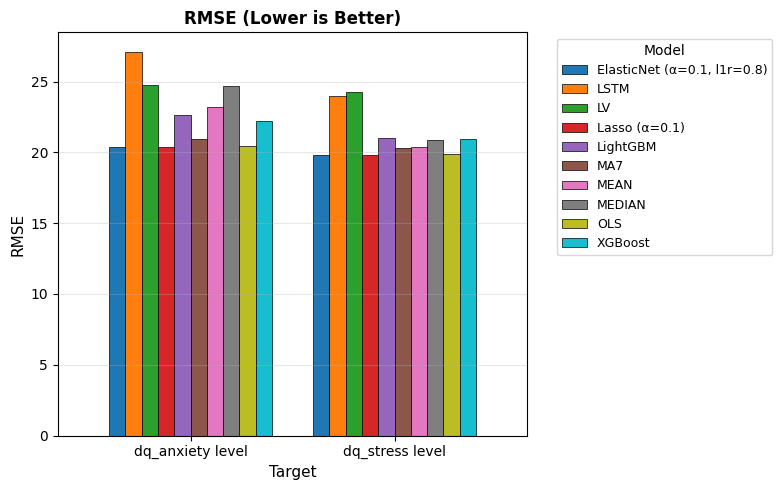

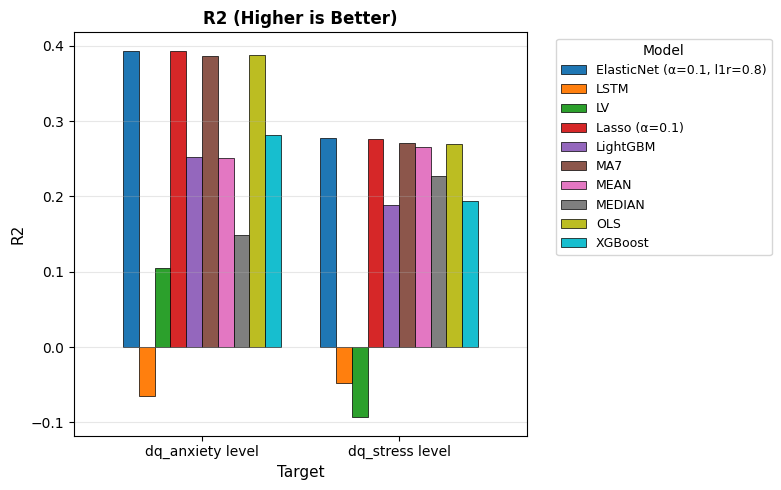

In [60]:
# Essential bar comparison charts (including LSTM) - separate figures for each metric
metrics = ['MAE', 'RMSE', 'R2']
for metric in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_data = all_results_extended.pivot(index="target", columns="model", values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{metric} {"(Lower is Better)" if metric in ["MAE", "RMSE"] else "(Higher is Better)"}', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel('Target', fontsize=11)
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()


### results using cross-validation are not included in the final results of the regression experiment